# 02 - Exploratory Data Analysis (EDA)

**MRP: Machine Learning-Based Auto Insurance Fraud Detection**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.titlesize"] = 12

df = pd.read_csv("car_insurance_clean.csv", parse_dates=["incident_date"])
print("Loaded cleaned data:", df.shape)

def fraud_rate_by(col):
    g = (df.groupby(col)["fraud"].mean() * 100).sort_values(ascending=False)
    return g

BASE_RATE = 100 * df["fraud"].mean()
print("Overall fraud rate (baseline): {:.2f}%".format(BASE_RATE))

Loaded cleaned data: (30000, 25)
Overall fraud rate (baseline): 11.47%


## 1. The target: how much fraud is there?

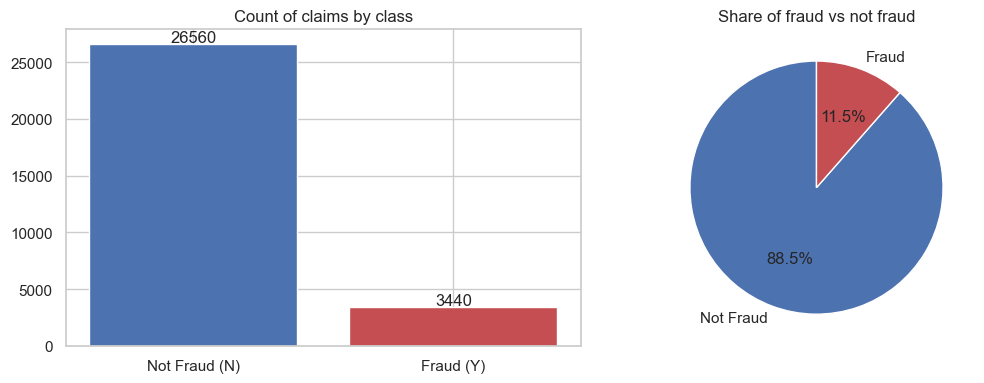

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df["fraud_reported"].value_counts()
ax[0].bar(["Not Fraud (N)", "Fraud (Y)"], counts.values, color=["#4C72B0", "#C44E52"])
ax[0].set_title("Count of claims by class")
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 200, str(v), ha="center")

ax[1].pie(counts.values, labels=["Not Fraud", "Fraud"], autopct="%1.1f%%",
          colors=["#4C72B0", "#C44E52"], startangle=90)
ax[1].set_title("Share of fraud vs not fraud")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

## 2. Customer features

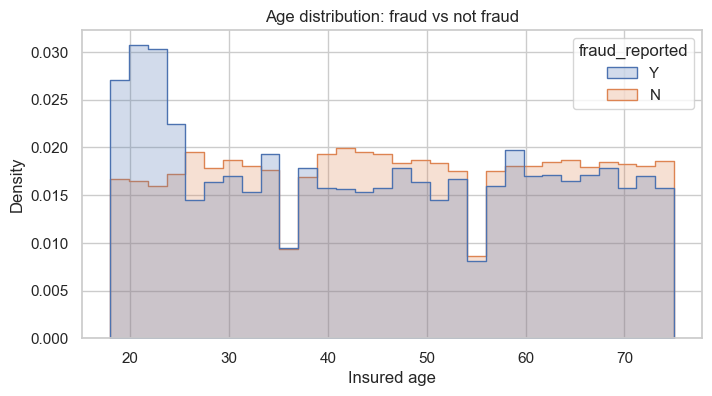

Average age - not fraud: 46.8
Average age -     fraud: 44.5


In [6]:
# Age distribution split by fraud
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="insured_age", hue="fraud_reported", bins=30,
             stat="density", common_norm=False, element="step")
plt.title("Age distribution: fraud vs not fraud")
plt.xlabel("Insured age")
plt.savefig("02_age_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

print("Average age - not fraud: {:.1f}".format(df.loc[df.fraud == 0, "insured_age"].mean()))
print("Average age -     fraud: {:.1f}".format(df.loc[df.fraud == 1, "insured_age"].mean()))

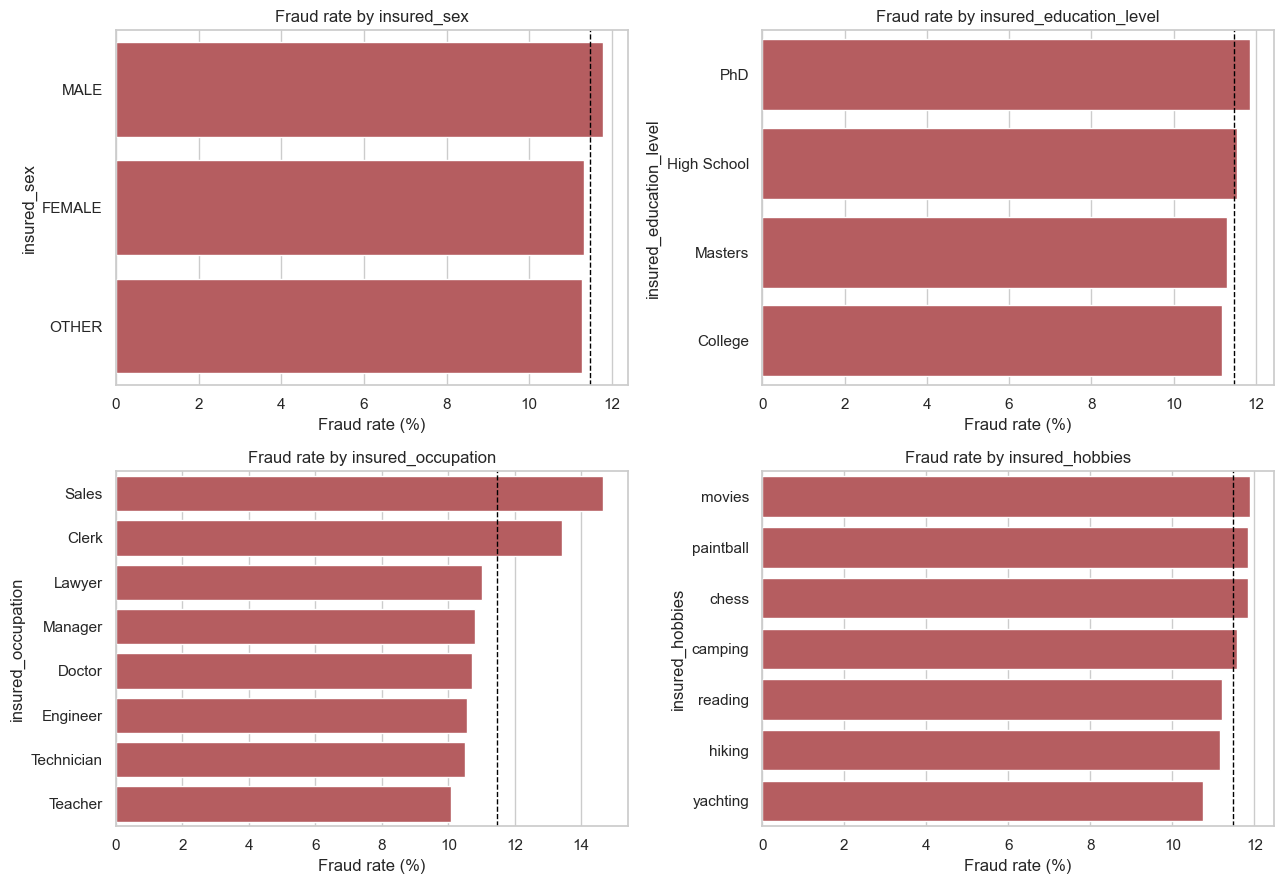

In [7]:
# Fraud rate by the categorical customer features
cust_cols = ["insured_sex", "insured_education_level", "insured_occupation", "insured_hobbies"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.ravel(), cust_cols):
    r = fraud_rate_by(col)
    sns.barplot(x=r.values, y=r.index, ax=ax, color="#C44E52")
    ax.axvline(BASE_RATE, color="black", ls="--", lw=1)
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("03_customer_fraud_rates.png", dpi=110, bbox_inches="tight")
plt.show()

## 3. Policy features

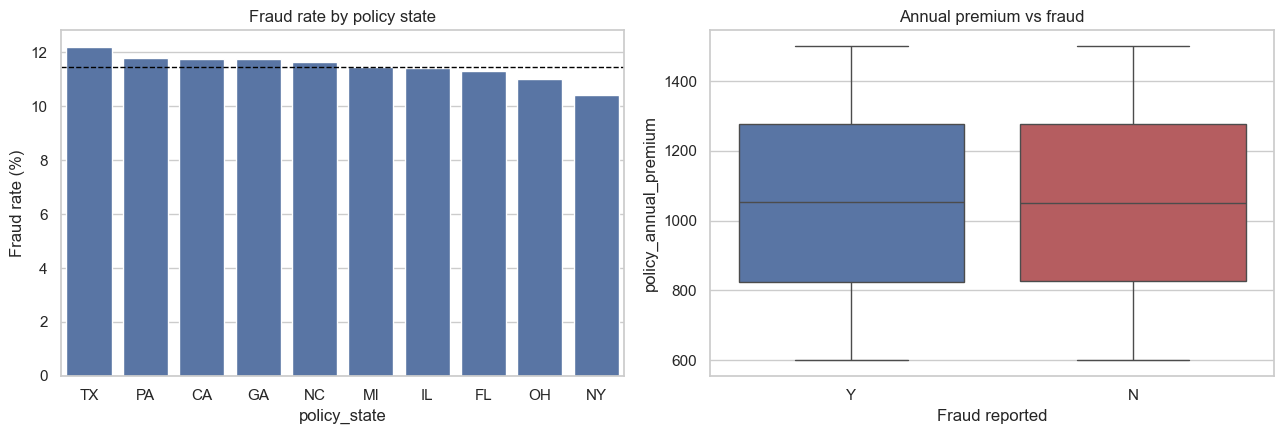

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Fraud rate by policy state
r = fraud_rate_by("policy_state")
sns.barplot(x=r.index, y=r.values, ax=axes[0], color="#4C72B0",
            order=r.index)
axes[0].axhline(BASE_RATE, color="black", ls="--", lw=1)
axes[0].set_title("Fraud rate by policy state")
axes[0].set_ylabel("Fraud rate (%)")

# Premium by fraud
sns.boxplot(data=df, x="fraud_reported", y="policy_annual_premium", ax=axes[1],
            hue="fraud_reported", legend=False, palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Annual premium vs fraud")
axes[1].set_xlabel("Fraud reported")
plt.tight_layout()
plt.savefig("04_policy_features.png", dpi=110, bbox_inches="tight")
plt.show()

## 4. Incident features

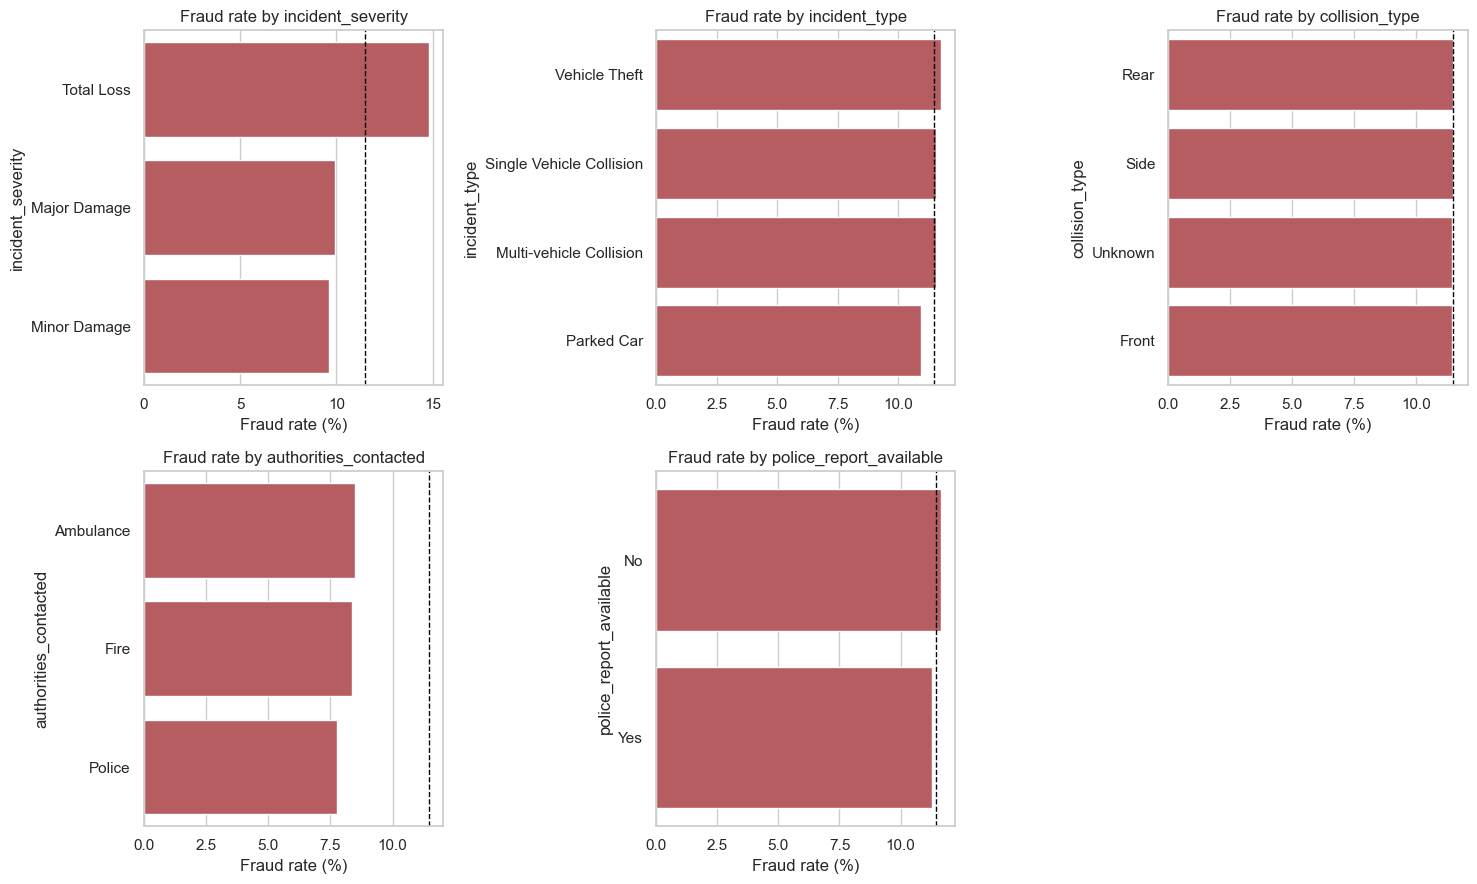

In [9]:
inc_cols = ["incident_severity", "incident_type", "collision_type",
            "authorities_contacted", "police_report_available"]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.ravel(), inc_cols):
    r = fraud_rate_by(col)
    sns.barplot(x=r.values, y=r.index, ax=ax, color="#C44E52")
    ax.axvline(BASE_RATE, color="black", ls="--", lw=1)
    ax.set_title(f"Fraud rate by {col}")
    ax.set_xlabel("Fraud rate (%)")
axes.ravel()[-1].axis("off")  # blank the 6th panel
plt.tight_layout()
plt.savefig("05_incident_fraud_rates.png", dpi=110, bbox_inches="tight")
plt.show()

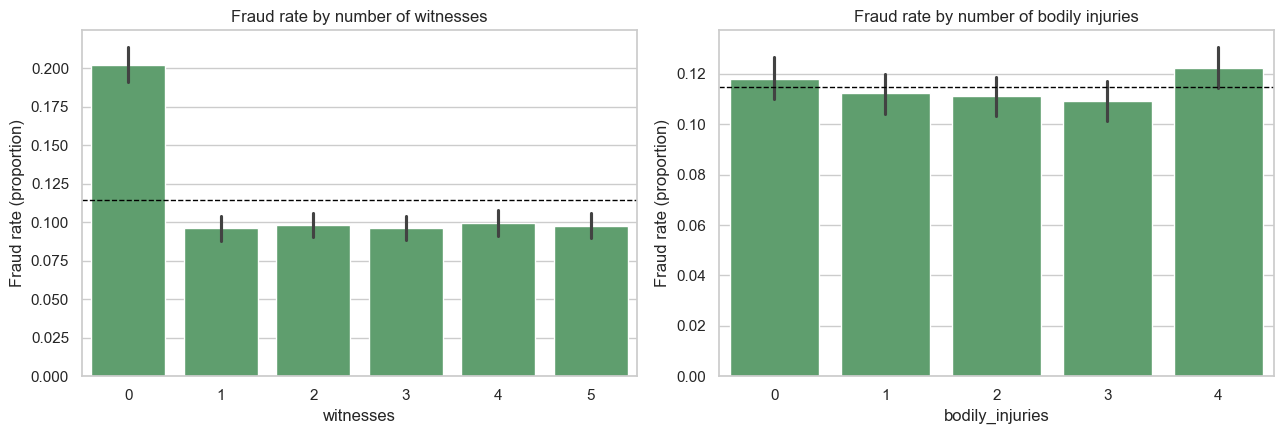

In [10]:
# Witnesses and bodily injuries vs fraud
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=df, x="witnesses", y="fraud", ax=axes[0], color="#55A868")
axes[0].axhline(df["fraud"].mean(), color="black", ls="--", lw=1)
axes[0].set_title("Fraud rate by number of witnesses")
axes[0].set_ylabel("Fraud rate (proportion)")

sns.barplot(data=df, x="bodily_injuries", y="fraud", ax=axes[1], color="#55A868")
axes[1].axhline(df["fraud"].mean(), color="black", ls="--", lw=1)
axes[1].set_title("Fraud rate by number of bodily injuries")
axes[1].set_ylabel("Fraud rate (proportion)")
plt.tight_layout()
plt.savefig("06_witnesses_injuries.png", dpi=110, bbox_inches="tight")
plt.show()

## 5. Money features (claim amounts)

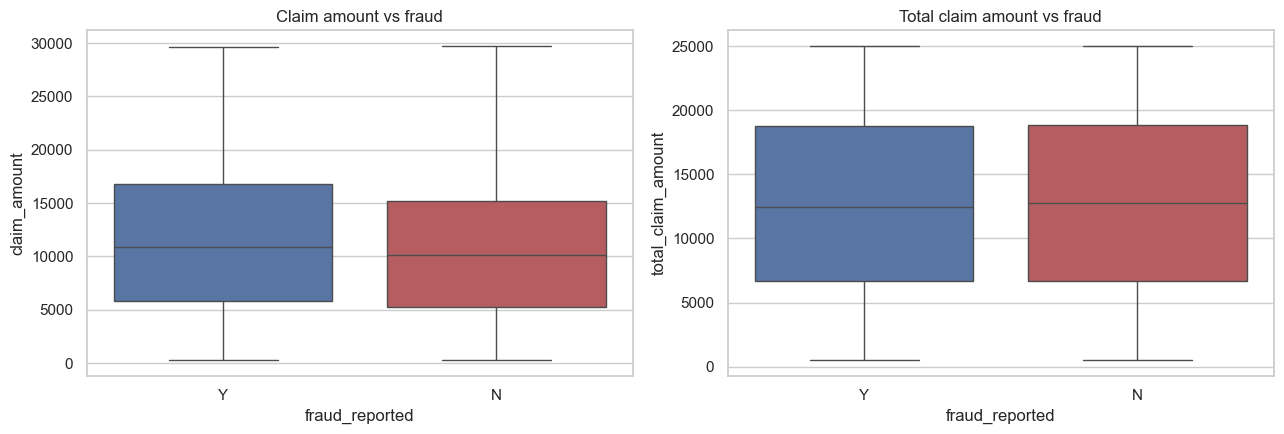

Mean claim_amount - fraud:     11596
Mean claim_amount - not fraud: 10723


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x="fraud_reported", y="claim_amount", ax=axes[0],
            hue="fraud_reported", legend=False, palette=["#4C72B0", "#C44E52"])
axes[0].set_title("Claim amount vs fraud")
sns.boxplot(data=df, x="fraud_reported", y="total_claim_amount", ax=axes[1],
            hue="fraud_reported", legend=False, palette=["#4C72B0", "#C44E52"])
axes[1].set_title("Total claim amount vs fraud")
plt.tight_layout()
plt.savefig("07_claim_amounts.png", dpi=110, bbox_inches="tight")
plt.show()

print("Mean claim_amount - fraud:     {:.0f}".format(df.loc[df.fraud == 1, "claim_amount"].mean()))
print("Mean claim_amount - not fraud: {:.0f}".format(df.loc[df.fraud == 0, "claim_amount"].mean()))

## 6. Correlation between numeric features

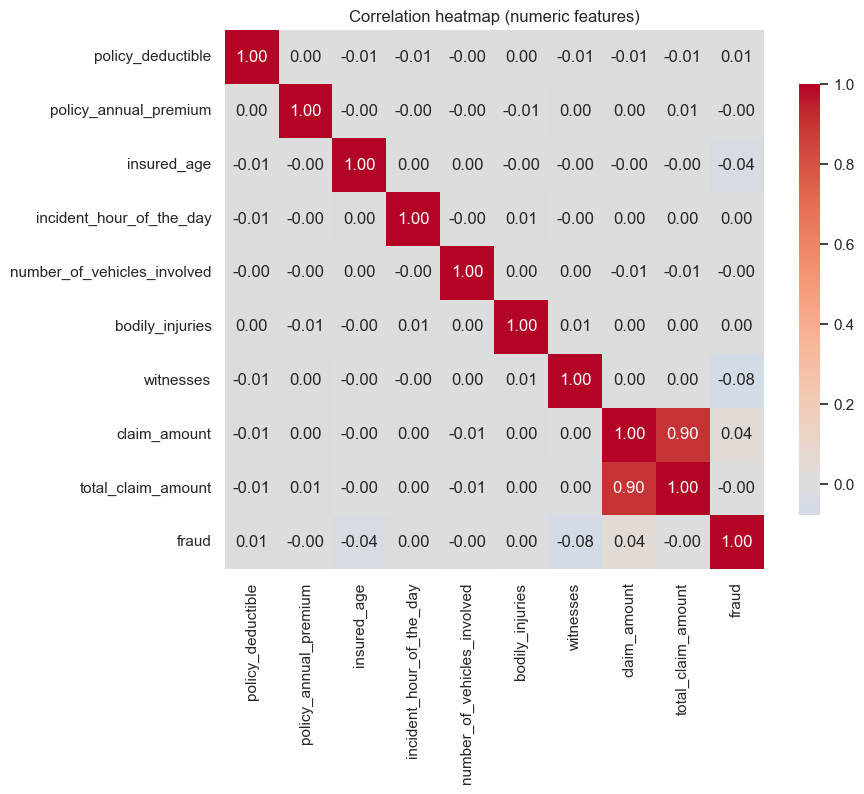

Correlation of each numeric feature with fraud:
witnesses                     -0.078
insured_age                   -0.044
claim_amount                   0.042
policy_deductible              0.007
total_claim_amount            -0.004
number_of_vehicles_involved   -0.003
bodily_injuries                0.002
incident_hour_of_the_day       0.002
policy_annual_premium         -0.001
Name: fraud, dtype: float64


In [12]:
num_cols = ["policy_deductible", "policy_annual_premium", "insured_age",
            "incident_hour_of_the_day", "number_of_vehicles_involved",
            "bodily_injuries", "witnesses", "claim_amount",
            "total_claim_amount", "fraud"]
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap (numeric features)")
plt.savefig("08_correlation_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

print("Correlation of each numeric feature with fraud:")
print(corr["fraud"].drop("fraud").sort_values(key=abs, ascending=False).round(3))

## 7. Temporal trends (Nov 2023 - Nov 2025)

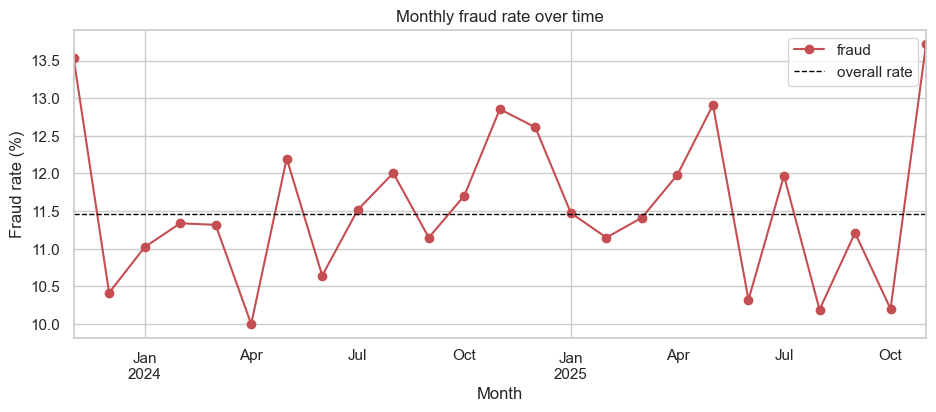

In [13]:
df["year_month"] = df["incident_date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("year_month")["fraud"].mean() * 100

plt.figure(figsize=(11, 4))
monthly.plot(marker="o", color="#C44E52")
plt.axhline(BASE_RATE, color="black", ls="--", lw=1, label="overall rate")
plt.title("Monthly fraud rate over time")
plt.ylabel("Fraud rate (%)")
plt.xlabel("Month")
plt.legend()
plt.savefig("09_monthly_trend.png", dpi=110, bbox_inches="tight")
plt.show()

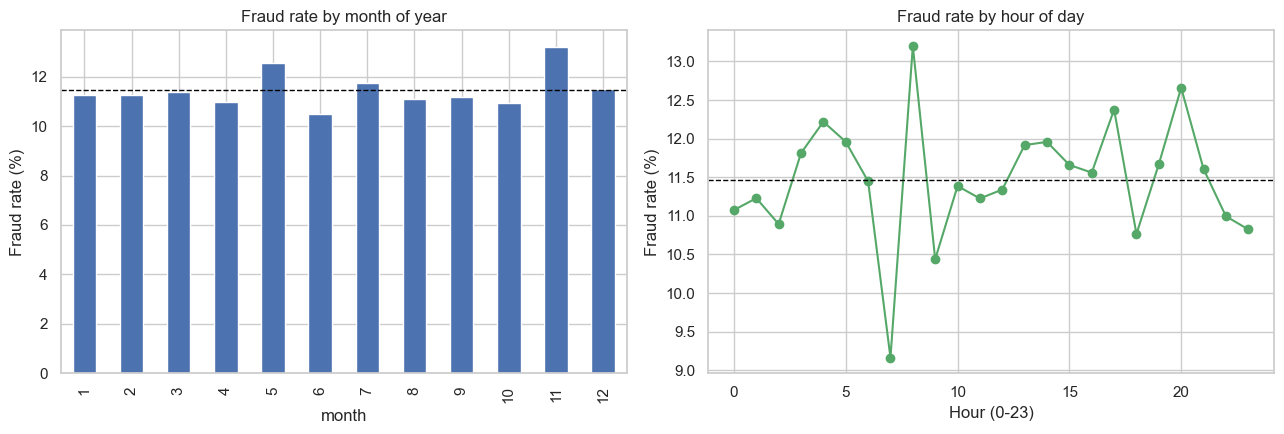

In [14]:
# Fraud rate by month-of-year and by hour-of-day
df["month"] = df["incident_date"].dt.month
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
(df.groupby("month")["fraud"].mean() * 100).plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].axhline(BASE_RATE, color="black", ls="--", lw=1)
axes[0].set_title("Fraud rate by month of year")
axes[0].set_ylabel("Fraud rate (%)")

(df.groupby("incident_hour_of_the_day")["fraud"].mean() * 100).plot(ax=axes[1], marker="o", color="#55A868")
axes[1].axhline(BASE_RATE, color="black", ls="--", lw=1)
axes[1].set_title("Fraud rate by hour of day")
axes[1].set_xlabel("Hour (0-23)")
axes[1].set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("10_month_hour.png", dpi=110, bbox_inches="tight")
plt.show()

## 8. Geographic differences

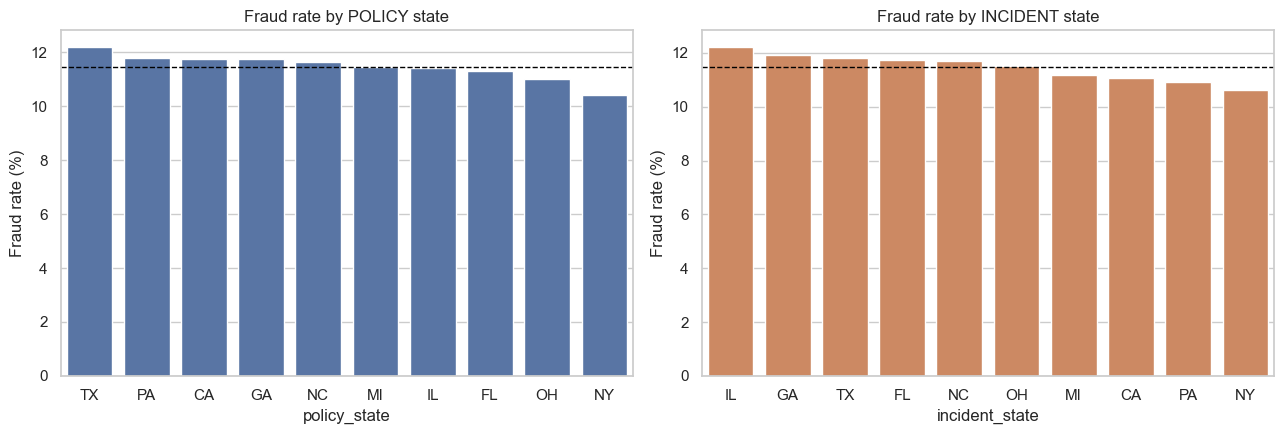

Fraud rate by policy state (%):
policy_state
TX    12.20
PA    11.78
CA    11.76
GA    11.75
NC    11.64
MI    11.45
IL    11.40
FL    11.30
OH    11.00
NY    10.42
Name: fraud, dtype: float64


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
r1 = fraud_rate_by("policy_state")
sns.barplot(x=r1.index, y=r1.values, ax=axes[0], color="#4C72B0", order=r1.index)
axes[0].axhline(BASE_RATE, color="black", ls="--", lw=1)
axes[0].set_title("Fraud rate by POLICY state")
axes[0].set_ylabel("Fraud rate (%)")

r2 = fraud_rate_by("incident_state")
sns.barplot(x=r2.index, y=r2.values, ax=axes[1], color="#DD8452", order=r2.index)
axes[1].axhline(BASE_RATE, color="black", ls="--", lw=1)
axes[1].set_title("Fraud rate by INCIDENT state")
axes[1].set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("11_geographic.png", dpi=110, bbox_inches="tight")
plt.show()

print("Fraud rate by policy state (%):")
print(fraud_rate_by("policy_state").round(2))